## Step 1: Load

In [1]:
QPY_DIR = 'artifacts/grover3-3'

In [2]:
from qiskit import qpy
import glob

# Alternative: Load the latest QPY circuit manually (if not using Step 1 cell)
# This cell is optional if you've already run Step 1

qpy_files = sorted(glob.glob(QPY_DIR + '/*.qpy'), reverse=True)
if not qpy_files:
    raise FileNotFoundError("No .qpy files found in the artifacts directory.")
qpy_path = qpy_files[0]

print(f'📁 Loading circuit: {qpy_path}')
with open(qpy_path, 'rb') as f:
    isa = list(qpy.load(f))[0]
print('✅ Circuit loaded')

📁 Loading circuit: artifacts/grover3-3/grover3_l3_ibm_fez_20251203_175232.qpy
✅ Circuit loaded


In [3]:
from quantum_executor import QuantumExecutor
qe = QuantumExecutor( config_file='quantum_config.json')
qe.run_circuit(isa_circuit=isa, execution_type='all')

qiskit_runtime_service._discover_account:WARNING:2025-12-07 12:06:19,529: Loading account with the given token. A saved account will not be used.


{'ideal': {'success': True,
  'execution_type': 'ideal_simulator',
  'backend': 'ibm_fez',
  'job_id': None,
  'counts': {'000': 265,
   '001': 277,
   '010': 277,
   '011': 251,
   '100': 281,
   '101': 239,
   '110': 225,
   '111': 6377},
  'probabilities': {'000': 0.0323486328125,
   '001': 0.0338134765625,
   '010': 0.0338134765625,
   '011': 0.0306396484375,
   '100': 0.0343017578125,
   '101': 0.0291748046875,
   '110': 0.0274658203125,
   '111': 0.7784423828125},
  'shots': 8192,
  'method': 'Aer SamplerV2'},
 'noisy': {'success': True,
  'execution_type': 'noisy_simulator',
  'backend': 'ibm_fez',
  'job_id': None,
  'counts': {'000': 268,
   '001': 302,
   '010': 255,
   '011': 400,
   '100': 309,
   '101': 340,
   '110': 367,
   '111': 5951},
  'probabilities': {'000': 0.03271484375,
   '001': 0.036865234375,
   '010': 0.0311279296875,
   '011': 0.048828125,
   '100': 0.0377197265625,
   '101': 0.04150390625,
   '110': 0.0447998046875,
   '111': 0.7264404296875},
  'shots': 8

## Step 2

In [3]:
from quantum_executor import QuantumExecutor
from delta_debug import run_delta_debug_on_isa
from delta_debug_visualizer import generate_html_report
# Step 2: Run Delta Debugging on the compiled ISA circuit `isa`
# The debugger automatically detects logical qubits from measurements

qe = QuantumExecutor(config_file='quantum_config.json')
result = run_delta_debug_on_isa(
    executor=qe,
    isa_circuit=isa,
    tolerance=0.01,  # Default tolerance 
    max_granularity=16,  # Max splitting depth
    test_mode=False
)

# ========== Generate and display the HTML visualization report ==========

# Generate the HTML report
html_path = generate_html_report(result)

# Display key information in English
print("\n📊 Key Findings:")
print(f"  • Total segments: {result['total_segments']}")
print(f"  • Problematic segments: {len(result['problematic_segments'])}")
print(f"  • Problematic segment IDs: {result['problematic_segments']}")
print(f"  • Baseline loss: {result['baseline_loss']:.4f}")
print(f"  • Test count: {result['test_count']}")

print(f"\n✅ HTML report generated: {html_path}")


qiskit_runtime_service._discover_account:WARNING:2025-12-03 18:52:34,573: Loading account with the given token. A saved account will not be used.


✅ HTML report generated: delta_debug_report_20251203_192251.html

📊 Key Findings:
  • Total segments: 39
  • Problematic segments: 10
  • Problematic segment IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  • Baseline loss: 0.1592
  • Test count: 51

✅ HTML report generated: delta_debug_report_20251203_192251.html
👇 See the interactive report below


In [ ]:
from analyze_problematic_segments import analyze_and_generate_circuits

analyze_and_generate_circuits("artifacts","tmp")

Loading 4 report(s) from artifacts/grover3-3/ (searched 2 levels deep)...
  ✓ Loaded: artifacts/grover3-3/delta_debug_report_20251203_181408.json
  ✓ Loaded: artifacts/grover3-3/delta_debug_report_20251203_182255.json
  ✓ Loaded: artifacts/grover3-3/delta_debug_report_20251203_183508.json
  ✓ Loaded: artifacts/grover3-3/delta_debug_report_20251203_192251.json
✓ Loaded 4 reports

Sequence Analysis Summary

📊 Reports analyzed: 4
📊 Total unique sequences: 104

📋 Top 10 Sequences (sorted by frequency)
  sx(107) → rz(107, -2.7489)
    Count: 6, Reports: [1, 2]
  rz(107, -2.7489) → sx(107)
    Count: 6, Reports: [1, 2]
  sx(107) → rz(107, -2.7489) → sx(107)
    Count: 6, Reports: [1, 2]
  sx(107) → rz(107, -3.1416)
    Count: 5, Reports: [0, 1, 2, 3]
  sx(107) → rz(107, 1.5708)
    Count: 4, Reports: [0, 2, 3]
  rz(97, 1.5708) → sx(97)
    Count: 3, Reports: [0, 2, 3]
  sx(97) → rz(97, 1.5708)
    Count: 3, Reports: [0, 2, 3]
  rz(97, 1.5708) → rz(106, 1.5708)
    Count: 3, Reports: [0, 2, 3

{'num_reports': 4,
 'all_sequences': {'sx(107) → rz(107, -2.7489)': {'count': 6,
   'reports': [1, 2],
   'operations': [{'operation': 'sx', 'qubits': (107,), 'params': ()},
    {'operation': 'rz', 'qubits': (107,), 'params': (-2.7488935718910694,)}]},
  'rz(107, -2.7489) → sx(107)': {'count': 6,
   'reports': [1, 2],
   'operations': [{'operation': 'rz',
     'qubits': (107,),
     'params': (-2.7488935718910694,)},
    {'operation': 'sx', 'qubits': (107,), 'params': ()}]},
  'sx(107) → rz(107, -2.7489) → sx(107)': {'count': 6,
   'reports': [1, 2],
   'operations': [{'operation': 'sx', 'qubits': (107,), 'params': ()},
    {'operation': 'rz', 'qubits': (107,), 'params': (-2.7488935718910694,)},
    {'operation': 'sx', 'qubits': (107,), 'params': ()}]},
  'sx(107) → rz(107, -3.1416)': {'count': 5,
   'reports': [0, 1, 2, 3],
   'operations': [{'operation': 'sx', 'qubits': (107,), 'params': ()},
    {'operation': 'rz', 'qubits': (107,), 'params': (-3.141592653589793,)}]},
  'sx(107) → r

## Step 3: Compare Circuits from tmp/circuits/

Compare all circuit segments using noisy simulator vs real device and calculate TVD loss


In [7]:
import verify_circuits
# Run circuit comparison
verify_circuits.verify_circuits()


qiskit_runtime_service._discover_account:WARNING:2025-12-03 19:24:57,690: Loading account with the given token. A saved account will not be used.


🔧 Initializing Quantum Executor...
📁 Found 10 QPY files

Processing: seq_001.qpy
Circuit: 2 qubits, 2 instructions
Physical qubits: [136, 143]
Virtual→Physical mapping: {'136': 0, '143': 1}
⚠️  Note: Circuit will be transpiled to use physical qubits [136, 143]
⚠️  No measurements found, adding measurements to all qubits...
   Added measurements to qubits: [0, 1]
Measured virtual qubits: [0, 1]
Measured physical qubits: [136, 143]
Measurement mapping: virtual_qubit→clbit {0: 0, 1: 1}

🔧 Remapping circuit to use original physical qubits [136, 143]...
✅ Circuit remapped to 144 qubits
   Operations now on physical qubits: [136, 143]
   Measured qubits: [136, 143]

🔧 Running noisy simulator (baseline)...
✅ Noisy simulator completed
   Projected counts: {'00': 3974, '10': 34, '01': 4152, '11': 32}

🚀 Running real device (test)...
✅ Real device completed (Job ID: d4of214fitbs739etrj0)
   Projected counts: {'00': 4224, '10': 2, '01': 3966}

📊 Total Variation Distance (TVD Loss): 0.061035

   S

🔍 Loading results...
✓ Loaded 10 circuit results

✅ Saved figure to: tmp/tvd_analysis.png


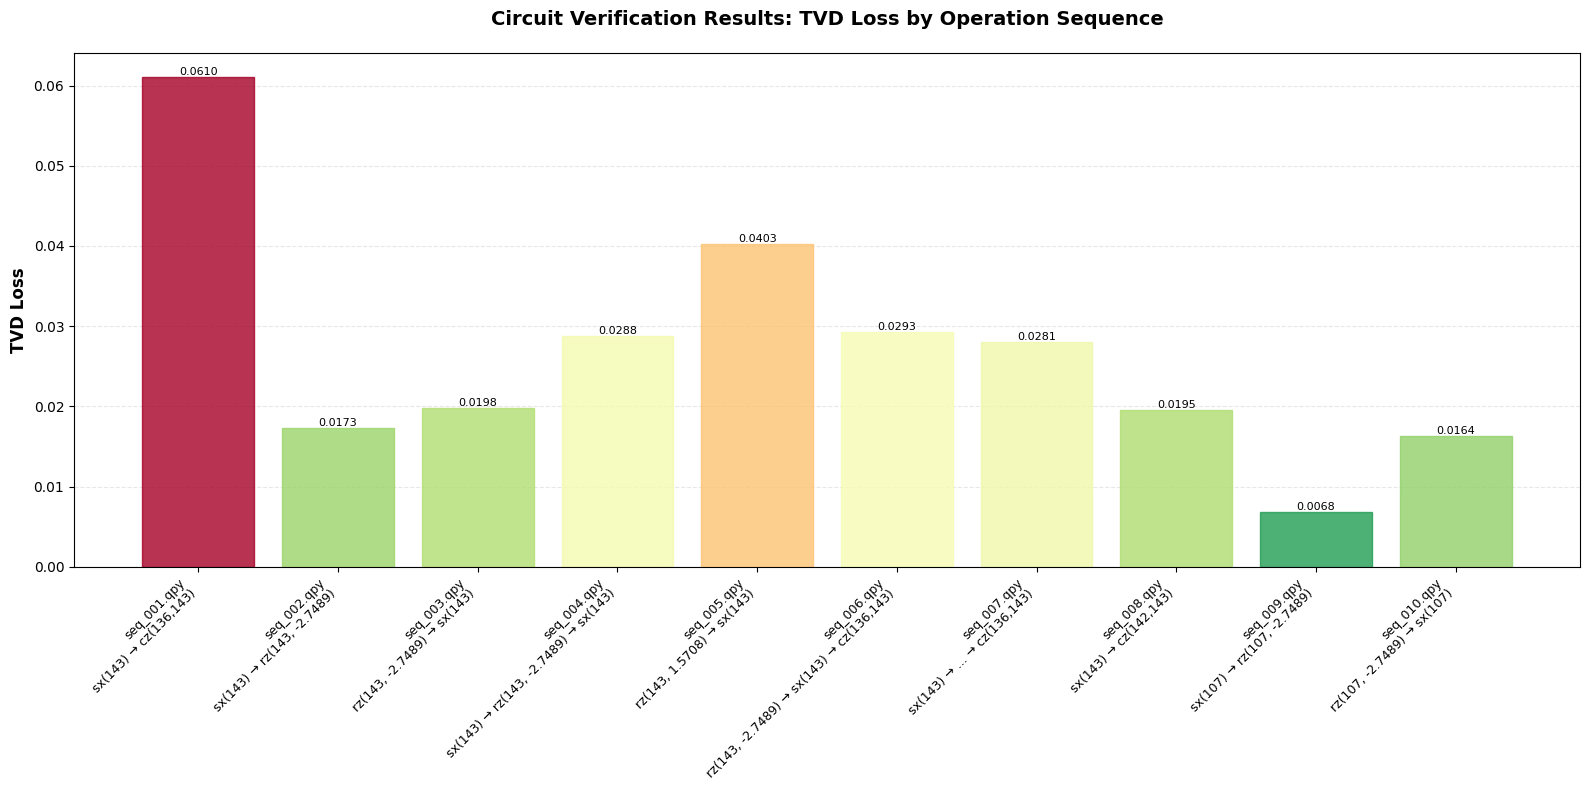


📊 Detailed Circuit Verification Summary

🔸 seq_001.qpy
   Operation Sequence: sx(143) → cz(136,143)
   TVD Loss: 0.061035
   Frequency: 15 times in reports [0, 1, 2, 4, 6, 8]

🔸 seq_002.qpy
   Operation Sequence: sx(143) → rz(143, -2.7489)
   TVD Loss: 0.017334
   Frequency: 11 times in reports [0, 1, 2, 4, 5, 6, 8]

🔸 seq_003.qpy
   Operation Sequence: rz(143, -2.7489) → sx(143)
   TVD Loss: 0.019775
   Frequency: 11 times in reports [0, 1, 2, 4, 5, 6, 8]

🔸 seq_004.qpy
   Operation Sequence: sx(143) → rz(143, -2.7489) → sx(143)
   TVD Loss: 0.028809
   Frequency: 11 times in reports [0, 1, 2, 4, 5, 6, 8]

🔸 seq_005.qpy
   Operation Sequence: rz(143, 1.5708) → sx(143)
   TVD Loss: 0.040283
   Frequency: 6 times in reports [0, 1, 4, 5, 6, 8]

🔸 seq_006.qpy
   Operation Sequence: rz(143, -2.7489) → sx(143) → cz(136,143)
   TVD Loss: 0.029297
   Frequency: 6 times in reports [0, 1, 2, 4, 8]

🔸 seq_007.qpy
   Operation Sequence: sx(143) → rz(143, -2.7489) → sx(143) → cz(136,143)
   TVD L

In [10]:
from visualize_results import main as visualize_main
visualize_main()